# Chapter 1 :The Bayasian paradigm for statistical Inference

## Python Lab sessions

## Exercise 1

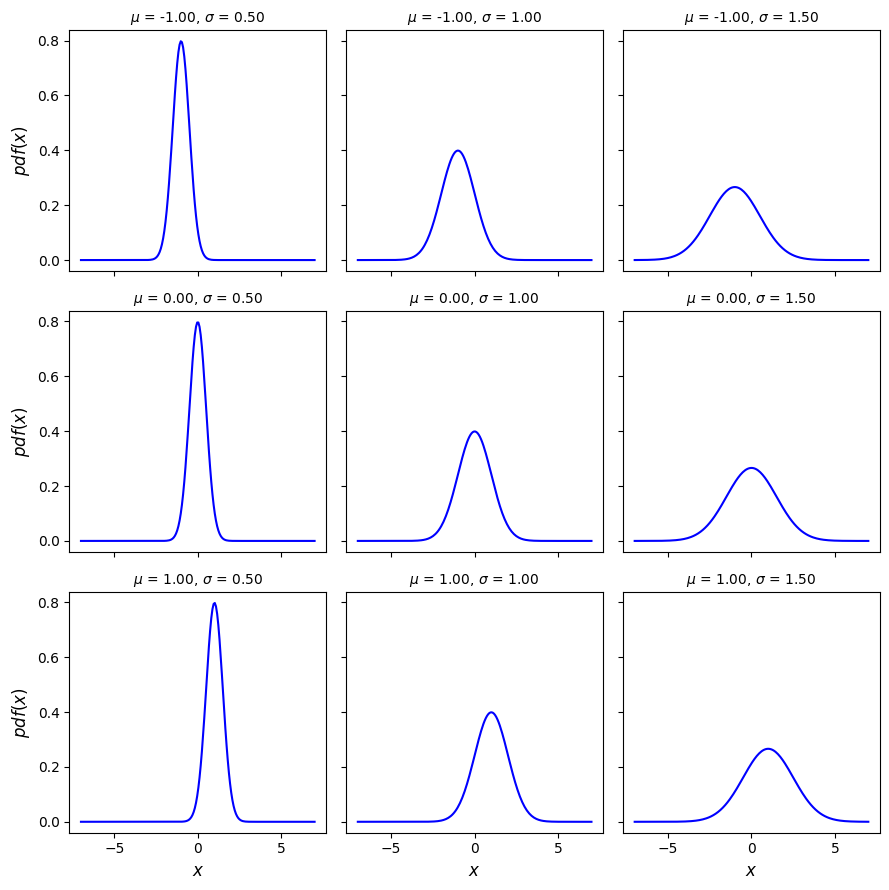

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

mu_params = [-1, 0, 1]
sd_params = [0.5, 1, 1.5]
x = np.linspace(-7, 7, 200)

f, ax = plt.subplots(len(mu_params), len(sd_params), sharex=True, sharey=True, figsize=(9, 9))

for i in range(len(mu_params)):
    for j in range(len(sd_params)):
        mu = mu_params[i]
        sd = sd_params[j]

        y = stats.norm(mu, sd).pdf(x)
        ax[i, j].plot(x, y, color='b')
        ax[i, j].set_title(rf'$\mu$ = {mu:.2f}, $\sigma$ = {sd:.2f}', fontsize=10)

# Axis labels (only outer edges)
for i in range(len(mu_params)):
    ax[i, 0].set_ylabel(r'$pdf(x)$', fontsize=12)

for j in range(len(sd_params)):
    ax[-1, j].set_xlabel(r'$x$', fontsize=12)

plt.tight_layout()
plt.show()

## Exercise 2

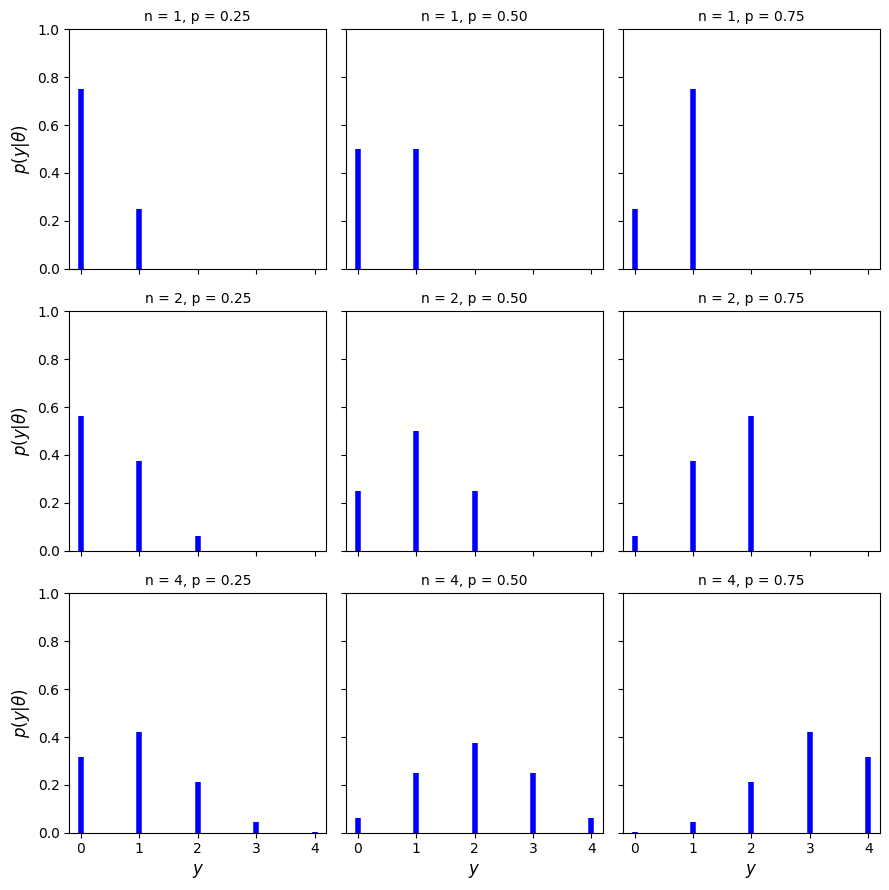

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n_params = [1, 2, 4]
p_params = [0.25, 0.5, 0.75]
x = np.arange(0, max(n_params) + 1)

f, ax = plt.subplots(len(n_params), len(p_params), sharex=True, sharey=True, figsize=(9, 9))

for i in range(len(n_params)):
    for j in range(len(p_params)):
        n = n_params[i]
        p = p_params[j]

        y = stats.binom(n=n, p=p).pmf(x)

        # Plot as vertical lines (discrete distribution)
        ax[i, j].vlines(x, 0, y, colors='b', lw=4)
        ax[i, j].set_ylim(0, 1)
        ax[i, j].set_title(f"n = {n}, p = {p:.2f}", fontsize=10)

        # Show only valid x values for each n
        ax[i, j].set_xticks(np.arange(0, n + 1))

# Axis labels (only outer edges)
for i in range(len(n_params)):
    ax[i, 0].set_ylabel(r'$p(y|\theta)$', fontsize=12)

for j in range(len(p_params)):
    ax[-1, j].set_xlabel(r'$y$', fontsize=12)

plt.tight_layout()
plt.show()

## Exercise 3

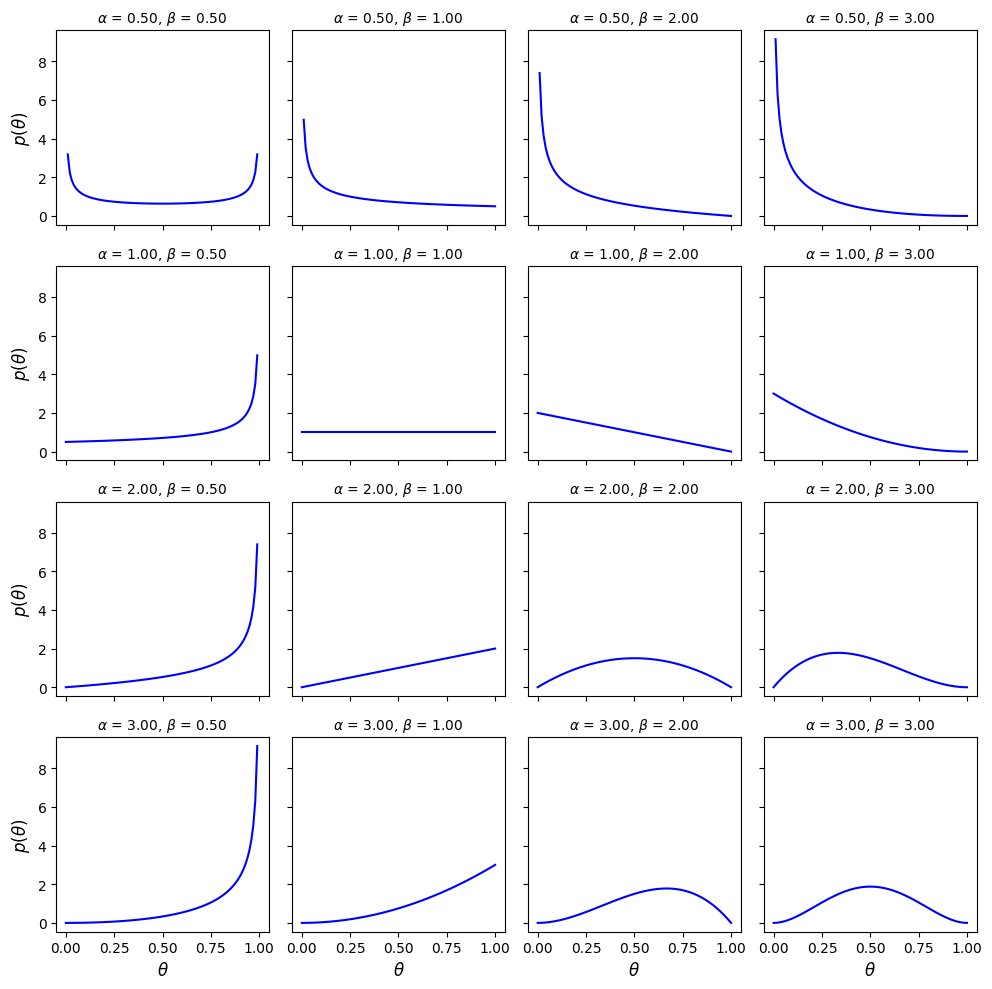

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

params = [0.5, 1, 2, 3]
x = np.linspace(0, 1, 100)

f, ax = plt.subplots(len(params), len(params), sharex=True, sharey=True, figsize=(10, 10))

for i in range(len(params)):
    for j in range(len(params)):
        a = params[i]
        b = params[j]

        y = stats.beta(a, b).pdf(x)
        ax[i, j].plot(x, y, color='b')
        ax[i, j].set_title(rf'$\alpha$ = {a:.2f}, $\beta$ = {b:.2f}', fontsize=10)

# Axis labels (only on outer edges for clarity)
for i in range(len(params)):
    ax[i, 0].set_ylabel(r'$p(\theta)$', fontsize=12)

for j in range(len(params)):
    ax[-1, j].set_xlabel(r'$\theta$', fontsize=12)

plt.tight_layout()
plt.show()

## Exercise 4

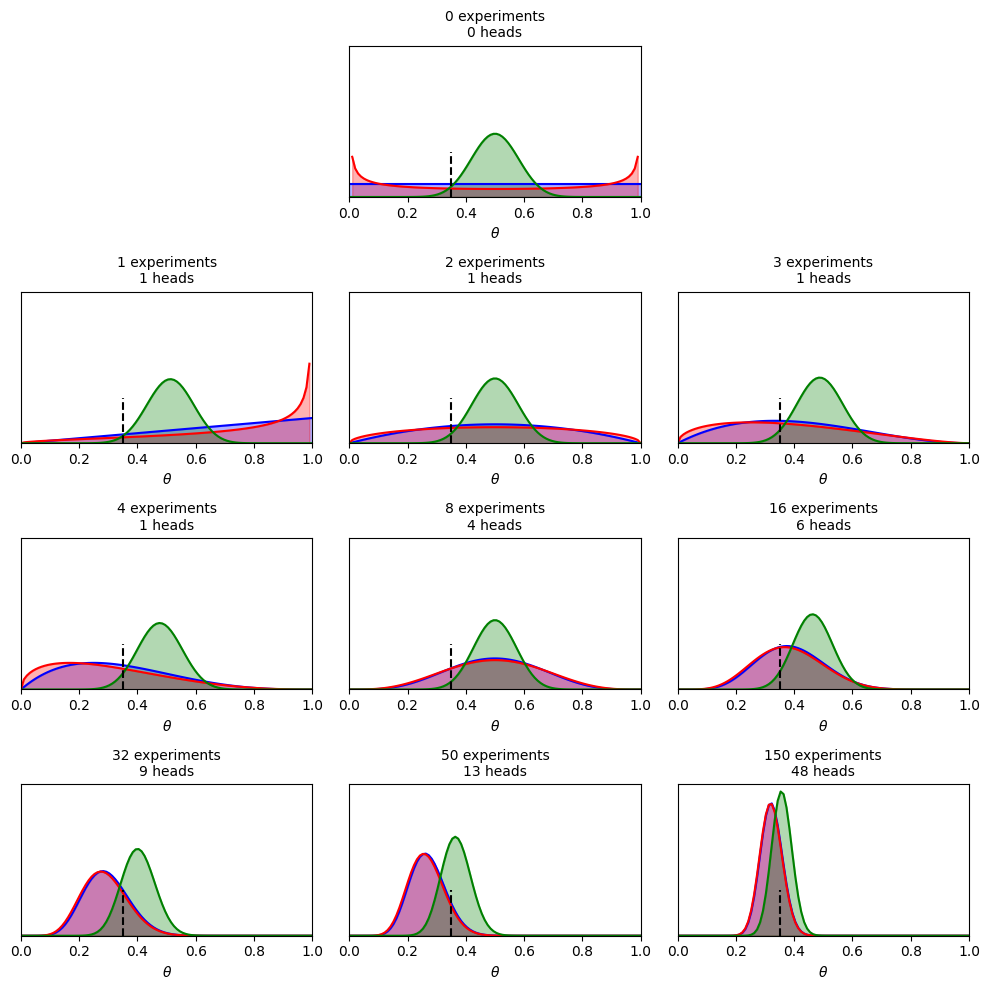

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

theta_real = 0.35
trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
data = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
beta_params = [(1, 1), (0.5, 0.5), (20, 20)]

dist = stats.beta
x = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 10))

for idx, N in enumerate(trials):
    if idx == 0:
        plt.subplot(4, 3, 2)
    else:
        plt.subplot(4, 3, idx + 3)

    y = data[idx]

    # Plot posterior distributions
    for (a_prior, b_prior), c in zip(beta_params, ('b', 'r', 'g')):
        p_theta_given_y = dist.pdf(x, a_prior + y, b_prior + N - y)
        plt.plot(x, p_theta_given_y, c)
        plt.fill_between(x, 0, p_theta_given_y, color=c, alpha=0.3)

    # True theta line
    plt.axvline(theta_real, ymax=0.3, color='k', linestyle='--')
    plt.title(f"{N} experiments\n{y} heads", fontsize=10)

    plt.xlim(0, 1)
    plt.ylim(0, 12)
    plt.xlabel(r'$\theta$')

    # for cleaner look
    plt.gca().axes.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

## Exercise 5

(0.0, 1.0)

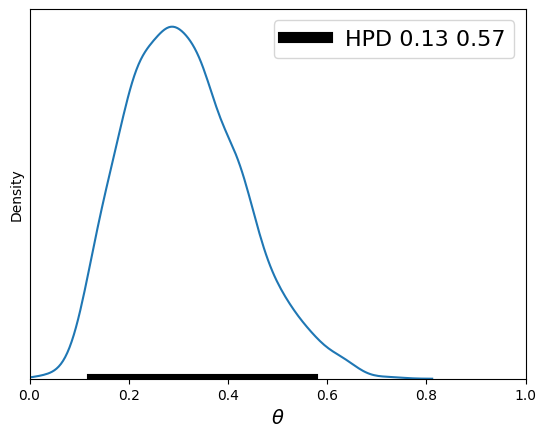

In [14]:
import seaborn as sns

def naive_hpd(post):
    sns.kdeplot(post)
    HPD = np.percentile(post, [2.5, 97.5])
    plt.plot(HPD, [0, 0], label='HPD {:.2f} {:.2f}'.format(*HPD), 
      linewidth=8, color='k')
    plt.legend(fontsize=16);
    plt.xlabel(r'$\theta$', fontsize=14)
    plt.gca().axes.get_yaxis().set_ticks([])
np.random.seed(1)
post = stats.beta.rvs(5, 11, size=1000)
naive_hpd(post)
plt.xlim(0, 1)

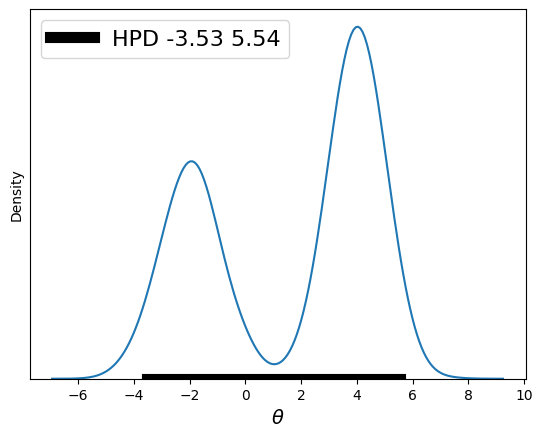

In [15]:
np.random.seed(1)    
gauss_a = stats.norm.rvs(loc=4, scale=0.9, size=3000)
gauss_b = stats.norm.rvs(loc=-2, scale=1, size=2000)
mix_norm = np.concatenate((gauss_a, gauss_b))
naive_hpd(mix_norm)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def plot_post(samples, roundto=2, alpha=0.05):
    samples = np.asarray(samples)

    # KDE for posterior
    kde = stats.gaussian_kde(samples)
    x = np.linspace(samples.min(), samples.max(), 500)
    y = kde(x)

    # Sort samples for HPD computation
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_idx = int(np.floor((1 - alpha) * n))

    # Find the shortest interval containing (1 - alpha) mass
    widths = sorted_samples[interval_idx:] - sorted_samples[:n - interval_idx]
    min_idx = np.argmin(widths)

    hpd_low = sorted_samples[min_idx]
    hpd_high = sorted_samples[min_idx + interval_idx]

    # Plot KDE
    plt.plot(x, y, label="Posterior")

    # Shade HPD region
    plt.fill_between(x, y, where=(x >= hpd_low) & (x <= hpd_high), alpha=0.3)

    # Mark HPD bounds
    plt.axvline(hpd_low, linestyle="--", label=f"HPD low = {round(hpd_low, roundto)}")
    plt.axvline(hpd_high, linestyle="--", label=f"HPD high = {round(hpd_high, roundto)}")

    # Mean
    mean = np.mean(samples)
    plt.axvline(mean, linestyle=":", label=f"Mean = {round(mean, roundto)}")

    return plt.gca()

Text(0.5, 0, '$\\theta$')

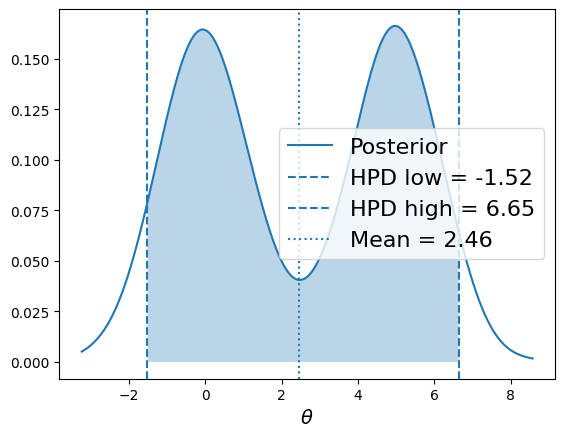

In [18]:

#from plot_post import plot_post
plot_post(mix_norm, roundto=2, alpha=0.05)
plt.legend(loc=0, fontsize=16)
plt.xlabel(r"$\theta$", fontsize=14)

In [19]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from hpd import hpd


def plot_post(param_sample_vec, cred_mass=0.95, comp_val=False,
              ROPE=False, ylab='', xlab='parameter', fontsize=14,
              labelsize=12, title='', framealpha=1,
              facecolor='skyblue', edgecolor='white',
              show_mode=True, bins=50):

    param_sample_vec = np.asarray(param_sample_vec)

    # ----------------------------
    # Compute HDI
    # ----------------------------
    HDI = hpd(param_sample_vec, 1 - cred_mass)

    # ----------------------------
    # Summary statistics
    # ----------------------------
    post_summary = {
        'mean': np.mean(param_sample_vec),
        'median': np.median(param_sample_vec),
        'mode': stats.mode(param_sample_vec, keepdims=True).mode[0],
        'hdi_mass': cred_mass,
        'hdi_low': HDI[0],
        'hdi_high': HDI[1],
        'comp_val': 0,
        'pc_gt_comp_val': 0,
        'ROPE_low': 0,
        'ROPE_high': 0,
        'pc_in_ROPE': 0
    }

    # ----------------------------
    # Histogram (posterior)
    # ----------------------------
    n, bins_edges, patches = plt.hist(
        param_sample_vec,
        density=True,   # updated (replaces normed=True)
        bins=bins,
        edgecolor=edgecolor,
        facecolor=facecolor
    )

    plt.xlabel(xlab, fontsize=fontsize)
    plt.ylabel(ylab, fontsize=fontsize)
    plt.title(title, fontsize=fontsize)

    # Heights for annotations
    cv_ht = 0.75 * np.max(n)
    cen_tend_ht = 0.9 * cv_ht
    ROPE_text_ht = 0.55 * cv_ht

    # ----------------------------
    # Mode / Mean label
    # ----------------------------
    if show_mode:
        plt.plot([], [], label='mode = %.2f' % post_summary['mode'])
    else:
        plt.plot([], [], label='mean = %.2f' % post_summary['mean'])

    # ----------------------------
    # Comparison value
    # ----------------------------
    if comp_val is not False:
        pc_gt_comp_val = 100 * np.mean(param_sample_vec > comp_val)
        pc_lt_comp_val = 100 - pc_gt_comp_val

        plt.plot([comp_val, comp_val], [0, cv_ht],
                 color='darkgreen', linestyle='--', linewidth=2,
                 label='%.1f%% < %.1f < %.1f%%'
                 % (pc_lt_comp_val, comp_val, pc_gt_comp_val))

        post_summary['comp_val'] = comp_val
        post_summary['pc_gt_comp_val'] = pc_gt_comp_val

    # ----------------------------
    # ROPE
    # ----------------------------
    if ROPE is not False:
        rope_col = 'darkred'

        pc_in_ROPE = 100 * np.mean(
            (param_sample_vec > ROPE[0]) &
            (param_sample_vec < ROPE[1])
        )

        plt.plot([ROPE[0], ROPE[0]], [0, 0.96 * ROPE_text_ht],
                 color=rope_col, linestyle=':', linewidth=3,
                 label='%.1f%% in ROPE' % pc_in_ROPE)

        plt.plot([ROPE[1], ROPE[1]], [0, 0.96 * ROPE_text_ht],
                 color=rope_col, linestyle=':', linewidth=3)

        post_summary['ROPE_low'] = ROPE[0]
        post_summary['ROPE_high'] = ROPE[1]
        post_summary['pc_in_ROPE'] = pc_in_ROPE

    # ----------------------------
    # HDI line
    # ----------------------------
    plt.plot(HDI, [0, 0],
             linewidth=6,
             color='black',
             label='HDI %.1f%% %.3f–%.3f'
             % (cred_mass * 100, HDI[0], HDI[1]))

    # Legend and formatting
    plt.legend(loc='upper left', fontsize=labelsize, framealpha=framealpha)
    plt.xlabel(xlab, fontsize=fontsize)

    frame = plt.gca()
    frame.axes.get_yaxis().set_ticks([])

    return post_summary

ModuleNotFoundError: No module named 'hpd'